# ECMWF Open Data — Catalog & Access Mechanisms

**Last updated:** 2026-05-09

---

## Learning objectives

By the end of this notebook you will be able to:

1. Describe what is in the ECMWF Free & Open Data catalogue and how it is organised
2. Understand the **IFS 50r1** naming changes (former HRES is now ENS control)
3. Browse the live index at `data.ecmwf.int` to discover available runs and steps
4. Download a GRIB2 file using three methods: `ecmwf-opendata` client, `curl`/`wget`, and HTTP Range
5. Inspect file contents with **earthkit.data** and plot a field by `shortName`

---

## Introduction

ECMWF's **Free and Open Data** is a curated subset of operational forecasts published under **CC BY 4.0** — no credentials required.  
It is available at `data.ecmwf.int` (FTP/HTTPS) and mirrored on AWS S3, Azure, and Google Cloud.

### What's in the catalogue (as of IFS Cycle 50r1, May 2026)

| Product | Stream / Type | Grid | Freq | Steps |
|---|---|---|---|---|
| IFS ENS control (`enfo/cf`) | replaces former HRES | 0.25° | 4×/day | 0–360 h |
| IFS ENS perturbed (`enfo/pf`) | 50 members | 0.25° | 2×/day | 0–360 h |
| AIFS-ENS v2 (`enfo/cf+pf`) | AI model | 0.25° | 4×/day | 0–360 h |
| IFS Waves deterministic (`wave`) | — | 0.25° | 4×/day | 0–360 h |
| IFS Waves ensemble (`waef`) | — | 0.25° | 2×/day | 0–360 h |
| TC tracks | BUFR | — | 4×/day | real-time |

> **50r1 naming change (12 May 2026):** The former deterministic HRES run no longer exists as a separate product.  
> The **IFS ENS control forecast** (`stream="enfo"`, `type="cf"`) is the direct replacement for most use cases.

### What's coming

- **Native 9 km resolution** in the free open subset — later in 2026 (currently 0.25°)
- **Full GRIB2** output (IFS 50r2, Q3 2026) — resolves the current GRIB1/GRIB2 mix

### Licence

All open data is published under [Creative Commons Attribution 4.0 (CC BY 4.0)](https://creativecommons.org/licenses/by/4.0/).  
Attribution required: *"Generated using Copernicus Climate Change Service information YYYY"* or *"ECMWF"*.

---

**Prerequisites:** Python 3.10+, `ecmwf-opendata`, `earthkit-data`, `earthkit-plots`, `requests`  
**Run time:** ~5 minutes (downloads ~5 MB)  
**Data:** live from `data.ecmwf.int` — no credentials needed


## ECMWF Open Data — quick facts & naming (50r1)

ECMWF Open Data uses a **0.25° global grid** in **GRIB2**. Data is regridded from native model resolution.

### Key naming since IFS Cycle 50r1 (12 May 2026)

- **`ifs-ens` control** (`stream="enfo"`, `type="cf"`) — replaces former HRES deterministic.  
  This is what most users previously called "HRES". If you have existing code using `stream="oper", type="fc"`, update to `stream="enfo", type="cf"`.
- **`ifs-ens` perturbed** (`stream="enfo"`, `type="pf"`) — 50 perturbed members.
- **`aifs-single`** — ECMWF AI model, `stream="oper"`, `type="fc"`. Available 4×/day.
- **`aifs-ens`** — AI ensemble, `stream="enfo"`, `type="cf"`/`"pf"`.
- **Waves deterministic** — `stream="wave"`, `type="fc"`.
- **Waves ensemble** — `stream="waef"`, `type="cf"`/`"pf"`.

### Access endpoints

| Method | URL / command | Notes |
|---|---|---|
| Python client | `pip install ecmwf-opendata` | Recommended |
| FTP/HTTPS | `data.ecmwf.int/forecasts/` | Browse live index |
| AWS S3 | `s3://ecmwf-forecasts/` (public) | No credentials |
| Azure STAC | Planetary Computer | See Notebook A03 |
| Google Cloud | `gs://ecmwf-open-data` (public) | See Notebook A03 |


## 1) Setup & imports

We start out by importing the required libraries and support functions in _utils. We also setup a **single cache** so every notebook stores data under `data/` at the repo root.

In [1]:
# Standard libs
from datetime import datetime, timedelta, timezone
from pathlib import Path
import re, requests
from bs4 import BeautifulSoup

# Earthkit
import earthkit.data as ekd
import earthkit.plots as ekp
from earthkit.data import from_source

# Project helpers
from _utils import get_data_dir, quick_plot

# One cache to rule them all
DATA_DIR = str(get_data_dir())
print("Data cache:", DATA_DIR)
print("earthkit-data:", ekd.__version__)
print("earthkit-plots:", getattr(ekp, "__version__", "unknown"))

Data cache: /Users/valtze/ecmwf-open-data-guide/data
earthkit-data: 0.19.4
earthkit-plots: 0.6.1


In [2]:
from datetime import datetime, timedelta, timezone

now = datetime.now(timezone.utc)

if   now.hour >= 22:  run_date = now;                     run_hour = 12  # today's 12z should be fully online
elif now.hour >= 10:  run_date = now;                     run_hour = 0   # today's 00z
else:                 run_date = now - timedelta(days=1); run_hour = 12  # yesterday 12z

fc_date = run_date.strftime("%Y%m%d")   # e.g. "20250903"
fc_time = f"{run_hour:02d}"             # "00" or "12"
print(f"Using model run: {fc_date} at {fc_time}z")


Using model run: 20260511 at 00z


## 2) Browse the live index

Here we mirror the public layout and discover available **steps** for following selection. We basically map out the data available in the FTP resource.

In [3]:
BASE = "https://data.ecmwf.int/forecasts"

RUNS_UTC = ["00", "06", "12", "18"]

MODEL_MAP = {
    "ifs-single":  {"parts": ["ifs", "0p25", "oper"],         "suffixes": ["oper-fc"]},
    "ifs-ens":     {"parts": ["ifs", "0p25", "enfo"],         "suffixes": ["enfo-ef", "enfo-em", "enfo-cf", "enfo-pf"]},
    "aifs-single": {"parts": ["aifs-single", "0p25", "oper"], "suffixes": ["oper-fc"]},
    "aifs-ens":    {"parts": ["aifs-ens", "0p25", "enfo"],    "suffixes": ["enfo-em", "enfo-pf", "enfo-cf"]},
    "wave-single": {"parts": ["ifs", "0p25", "wave"],         "suffixes": ["wave-fc"]},
    "wave-ens":    {"parts": ["ifs", "0p25", "waef"],         "suffixes": ["waef-cf", "waef-pf"]},
}

def get_index_url(date_str, run_h, model_key):
    m = MODEL_MAP[model_key]
    run_str = f"{run_h:02d}z" if isinstance(run_h, int) else f"{run_h}z"
    parts = [BASE, date_str, run_str] + m["parts"]
    return "/".join(parts) + "/"


def available_steps(date_str, run_str, model_key):
    m = MODEL_MAP[model_key]
    run_z = f"{run_str}z" if not str(run_str).endswith("z") else run_str
    parts = [BASE, date_str, run_z] + m["parts"]
    dir_url = "/".join(parts) + "/"
    suffix = m["suffixes"][0]
    
    try:
        import requests, re
        r = requests.get(dir_url, timeout=15)
        r.raise_for_status()
        pattern = re.compile(r'\d{12}-(\d+)h-' + re.escape(suffix) + r'\.grib2')
        steps = sorted(set(int(x) for x in pattern.findall(r.text)))
        return dir_url, steps, suffix
    except Exception as e:
        return dir_url, [], suffix    

## 3. Preflight & download — pin a safe run and cache what we’ll use

**Why this step**  
We start with a **safe IFS run** (00z or 12z with a small publish buffer) and download only the files used later. Everything is cached under `./data`, and each file is validated (so half-downloads don’t sneak in).

**What this cell does**
- Picks a conservative run if `fc_date`/`fc_time` are not set (or reuses yours).
- Tries that run first; if not online yet, **falls back to latest**.
- Fetches a compact set of files:
  - **HRES sfc**: `msl/2t/10u/10v`, step 0
  - **HRES 2t time series**: steps 0..24 by 3 h
  - **ENS 2t time series**: **PF** and **CF**, steps 0..24 by 3 h
  - **HRES PL (t/u/v/r)**: step 0 (for the sounding)
  - **Waves**: deterministic (`wave`) and ENS control (`waef`), step 0
  - **AIFS single**: `msl/2t`, step 0 (for AIFS–IFS comparisons)
- Updates `fc_date`/`fc_time` to the **actual run used** so plot titles match reality.
- Prints a short summary with file sizes; missing items are shown as “(missing)”.

**Tip**  
If you want more horizon, increase the step lists here and re-run.


Browse & select a file that actually exists

Pick a **model family**, **date** (last 4 UTC days), **run** (00/06/12/18), and then a **step** from the list we discover live from the index.  
We only show steps that exist for your selection.

- If no steps appear: try a different run (e.g., `00` instead of `12`) or the previous UTC day.
- The file will be saved under `./data/` with the exact remote filename.


In [4]:
# --- Minimal helpers used by the widget ---

def _as_int(x, *, none_ok=False):
    """Cast ints or strings like '00' to int. None -> error unless none_ok=True."""
    if x is None:
        if none_ok:
            return None
        raise ValueError("Expected int-like value, got None")
    return int(str(x))

def build_filename(date_str, run_str, step_h, suffix):
    """
    Robust file name builder; accepts str/int; handles step==0; rejects Nones.
    Example: 20250908120000-6h-oper-fc.grib2
    """
    if not date_str:
        raise ValueError("date_str is required")
    if suffix is None:
        raise ValueError("suffix is required")
    run_i  = _as_int(run_str)
    step_i = _as_int(step_h)
    ts = f"{str(date_str)}{run_i:02d}0000"  # YYYYMMDDHHMMSS
    return f"{ts}-{step_i}h-{suffix}.grib2"


In [5]:
# --- Original-style picker with safe defaults + step==0 fix + no duplicate prints ---

import ipywidgets as widgets
from IPython.display import display, Markdown
from pathlib import Path
import requests

# rolling 4 UTC days (newest first)
try:
    date_opts = recent_utc_dates(4)  # your existing helper
except NameError:
    from datetime import datetime, timedelta, timezone
    today = datetime.now(timezone.utc).date()
    date_opts = [(today - timedelta(days=i)).strftime("%Y%m%d") for i in range(4)]

# ensure fc_date/fc_time are present in options
if 'fc_date' in globals() and fc_date not in date_opts:
    date_opts = [fc_date] + [d for d in date_opts if d != fc_date]

# widgets (create first)
model_dd = widgets.Dropdown(description="Model", options=list(MODEL_MAP.keys()), value=list(MODEL_MAP.keys())[0])
date_dd  = widgets.Dropdown(description="Date (UTC)", options=date_opts, value=date_opts[0])
run_dd   = widgets.Dropdown(description="Run (UTC)", options=RUNS_UTC, value=RUNS_UTC[0])
step_dd  = widgets.Dropdown(description="Step (h)", options=[], disabled=True)

download_btn = widgets.Button(description="Download file", button_style="primary", disabled=True)
out = widgets.Output()

# globals for later cells (unchanged)
target = None
date_str = run_str = model_key = None
step_h = None
dir_url = ""
product_suffix = None

# guard to avoid duplicate prints when we programmatically set step_dd.value
_setting_step = False

# ---- set safe defaults BEFORE wiring observers ----
try:
    if fc_date in date_dd.options: date_dd.value = fc_date
    if fc_time in run_dd.options:  run_dd.value  = fc_time
except NameError:
    pass

def refresh_steps(*_):
    global date_str, run_str, model_key, step_h, dir_url, product_suffix, _setting_step
    with out:
        out.clear_output(wait=True)
        try:
            dstr, rstr, mkey = date_dd.value, run_dd.value, model_dd.value
            durl, steps, suf = available_steps(dstr, rstr, mkey)
            if not steps:
                step_dd.options = []; step_dd.disabled = True; download_btn.disabled = True
                print("No steps found. Try another date/run/model.")
                return

            steps = [int(s) for s in steps]  # ensure ints, so 0 behaves
            # avoid firing on_step_change while we set the value
            _setting_step = True
            try:
                step_dd.unobserve(on_step_change, names="value")
                step_dd.options = steps
                default_step = steps[0]
                step_dd.value = default_step
            finally:
                step_dd.observe(on_step_change, names="value")
                _setting_step = False

            step_dd.disabled = False
            download_btn.disabled = False

            # stash globals
            date_str, run_str, model_key = dstr, rstr, mkey
            step_h = int(step_dd.value)
            dir_url = durl
            product_suffix = suf

            # print selection ONCE (we do not print inside on_step_change when _setting_step is True)
            fname = build_filename(date_str, run_str, step_h, product_suffix)
            display(Markdown(
                f"**Selected**: `{model_key}` — `{date_str}` `{run_str}` — step `{step_h}`  \n"
                f"**Model**: `{product_suffix}`  \n"
                f"**File**: `{fname}`"
            ))
        except Exception as e:
            step_dd.options = []; step_dd.disabled = True; download_btn.disabled = True
            print("Failed to list steps:", repr(e))

def on_step_change(change):
    global date_str, run_str, model_key, step_h, dir_url, product_suffix, _setting_step
    # Ignore traitlets noise and programmatic updates during refresh
    if change.get("name") != "value" or change.get("new") is None or _setting_step:
        return

    dstr, rstr, mkey = date_dd.value, run_dd.value, model_dd.value
    durl, _, suf = available_steps(dstr, rstr, mkey)

    date_str, run_str, model_key = dstr, rstr, mkey
    step_h = _as_int(change["new"])   # robust cast
    dir_url = durl
    product_suffix = suf
    with out:
        out.clear_output(wait=True)
        fname = build_filename(date_str, run_str, step_h, product_suffix)
        display(Markdown(
            f"**Selected**: `{model_key}` — `{date_str}` `{run_str}` — step `{step_h}`  \n"
            f"**Product**: `{product_suffix}`  \n"
            f"**File**: `{fname}`"
        ))

def on_download(_):
    global target
    with out:
        out.clear_output(wait=True)

        # Shared data dir
        try:
            from _utils import get_data_dir
            DATA_DIR = get_data_dir()
        except Exception:
            DATA_DIR = Path("data"); DATA_DIR.mkdir(exist_ok=True)

        fname = build_filename(date_str, run_str, step_h, product_suffix)
        file_url = f"{dir_url}{fname}"
        target = DATA_DIR / fname

        print("Downloading:", file_url)
        try:
            with requests.get(file_url, stream=True, timeout=60) as r:
                r.raise_for_status()
                with open(target, "wb") as f:
                    for chunk in r.iter_content(1024 * 1024):
                        if chunk: f.write(chunk)
            print("Saved:", target, f"({target.stat().st_size/1e6:.1f} MB)")

            # keep following cells working unchanged
            globals()['target'] = target
            globals()['date_str'] = date_str
            globals()['run_str']  = run_str
            globals()['step_h']   = step_h
            globals()['dir_url']  = dir_url
            globals()['product_suffix'] = product_suffix

        except Exception as e:
            target = None
            print("Download failed:", repr(e))

# wire observers AFTER defaults are set
for w in (model_dd, date_dd, run_dd):
    w.observe(refresh_steps, names="value")
step_dd.observe(on_step_change, names="value")
download_btn.on_click(on_download)

display(widgets.VBox([model_dd, widgets.HBox([date_dd, run_dd]), step_dd, download_btn, out]))

# initial populate
refresh_steps()


In [8]:
# --- Compatibility shim for older cells that expect `picker` ---
from pathlib import Path

# Ensure your download cell defines `target` as the saved GRIB path:
# e.g. target = Path("data/hres_msl_2t_10uv.grib2")

try:
    picker  # if a real widget exists, do nothing
except NameError:
    class _PickerShim:
        def __init__(self, path):
            self.last_path = Path(path) if path else None
        def get_selected_local_path(self):
            return self.last_path

    # expose a stable var novices can use elsewhere too
    TARGET_GRIB = Path(globals().get("target")) if globals().get("target") else None
    picker = _PickerShim(TARGET_GRIB)


## 4) Explore

Once the data is saved we can open the downloaded GRIB with Earthkit and inspect it in a concise inventory.  
We will use the `shortName` column (e.g., `2t`, `msl`, `tp`) for plotting next.


In [9]:
# Explore: prefer the widget's picker; fall back to `target` saved by the Download button
from pathlib import Path
from earthkit.data import from_source

p = None

# 1) Try the widget
if 'picker' in globals():
    try:
        p = getattr(picker, 'last_path', None) or (
            picker.get_selected_local_path() if hasattr(picker, 'get_selected_local_path') else None
        )
    except Exception:
        p = None

# 2) Fall back to the explicit path set by the download step
if (p is None or not Path(p).exists()) and globals().get('target'):
    p = Path(globals()['target'])

# 3) Friendly error if nothing was downloaded
if not p or not Path(p).exists():
    raise FileNotFoundError("No file downloaded yet. Use the Download button first.")

ds = from_source("file", str(p))
ds.describe()


,,level,date,time,step,number,paramId,class,stream,type,experimentVersionNumber
shortName,typeOfLevel,,,,,,,,,,
100u,heightAboveGround,100,20260511,0,0,None,228246,od,oper,fc,0001
100v,heightAboveGround,100,20260511,0,0,None,228247,od,oper,fc,0001
10fg,heightAboveGround,10,20260511,0,0,None,49,od,oper,fc,0001
10u,heightAboveGround,10,20260511,0,0,None,165,od,oper,fc,0001
10v,heightAboveGround,10,20260511,0,0,None,166,od,oper,fc,0001
2d,heightAboveGround,2,20260511,0,0,None,168,od,oper,fc,0001
2t,heightAboveGround,2,20260511,0,0,None,167,od,oper,fc,0001
asn,surface,0,20260511,0,0,None,32,od,oper,fc,0001
d,isobaricInhPa,"100,200,...",20260511,0,0,None,155,od,oper,fc,0001


## 5) Plot by `shortName`

Run the cell and type one of the `shortName` values in the widget, selecting one from the table we generated in previous step.  
If the plot fails, please check the spelling and try a another parameter.

Output()

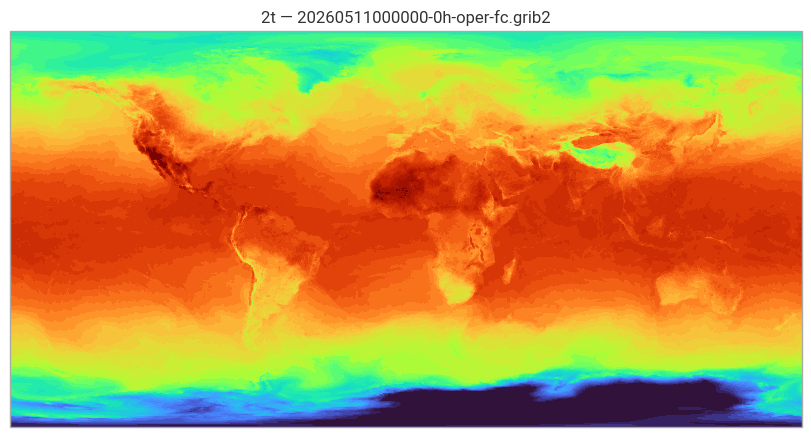

In [10]:
import ipywidgets as widgets
from IPython.display import display

param = widgets.Text(description="shortName", placeholder="e.g. 2t, msl, tp")
plot_btn = widgets.Button(description="Plot", button_style="primary")
outp = widgets.Output()

def _plot(_):
    with outp:
        outp.clear_output()
        name = (param.value or "").strip().lower()
        if not name:
            print("Type a shortName from the Explore table above (e.g. 2t, msl, tp).")
            return
        for i, f in enumerate(ds):
            sn = (f.metadata().get("shortName") or "").lower()
            if sn == name:
                try:
                    quick_plot(ds[i], title=f"{name} — {Path(target).name}")
                except Exception as e:
                    print("Plot failed for this field:", repr(e))
                return
        print(f"shortName '{param.value}' not found. Check the Explore table and try again.")

plot_btn.on_click(_plot)
display(widgets.HBox([param, plot_btn]), outp)

## Appendix · CLI & Python downloads

To wrap our basic introduction to ECMWF open-data, we will also explore short examples of data access for slighlty more advanced programmatic access. You can reuse the printed examples and run them in your terminal or use these as foundation to **script** or **automate** downloads outside the notebook.

**Naming:** we save using the **remote filename** (e.g., `20250905120000-0h-oper-fc.grib2`), matching what you see on the ECMWF index page.

> If the rolling archive has updated (you started with this notebook a couple hours before), please refresh by re-running the selector cells on top (code cell 2 and 3) first, and then re-run the URL cell below.


In [11]:
# --- Appendix bridge for A01: recreate picker-like state + FILENAME/IDX ---
from pathlib import Path
import re

# 0) Resolve the GRIB file path produced by your download cell
p = None
for name in ("TARGET_GRIB", "target"):
    if name in globals() and globals()[name]:
        p = Path(globals()[name])
        break

if not p or not p.exists():
    raise FileNotFoundError(
        "No downloaded GRIB found. Run the download cell first (it should set `target` or `TARGET_GRIB`)."
    )

# 1) Ensure a shared data dir
try:
    from _utils import get_data_dir
    DATA_DIR = get_data_dir()
except Exception:
    DATA_DIR = Path("data"); DATA_DIR.mkdir(exist_ok=True)

# 2) Parse filename: YYYYMMDDHHMMSS-<step>h-<suffix>.grib2
m = re.match(r'^(?P<ts>\d{14})-(?P<step>\d+)h-(?P<suffix>[^.]+)\.grib2$', p.name)

if m:
    ts = m.group("ts")
    date_str = ts[:8]        # YYYYMMDD
    run_str  = ts[8:10]      # HH
    step_h   = int(m.group("step"))
    product_suffix = m.group("suffix")  # e.g. oper-fc, enfo-ef, wave-fc, waef-ef
else:
    # Fallbacks if the filename can't be parsed (shouldn't happen with standard names)
    date_str = globals().get("fc_date", "????????")
    run_str  = globals().get("fc_time", "??")
    step_h   = int(globals().get("step_h", 0))
    product_suffix = "oper-fc"

# 3) Reconstruct the directory URL (A01 uses IFS 0p25 products)
# stream is before the dash in the suffix: oper / enfo / wave / waef
stream = product_suffix.split("-")[0]
model_root = "ifs"  # A01 uses IFS products
dir_url = f"https://data.ecmwf.int/forecasts/{date_str}/{run_str}z/{model_root}/0p25/{stream}/"

# 4) Variables appendix cells expect
FILENAME = p.name
FILE_URL = dir_url + FILENAME
IDX      = FILE_URL + ".index"   # per-file JSON index for byte-range demos

# 5) Minimal picker shim with .state (to satisfy appendix code)
class _PickerShim:
    def __init__(self, local_path):
        self.last_path = Path(local_path)
        self.state = {
            "date":   date_str,
            "run":    run_str,
            "model":  "ifs-single",   # not used by the appendix, but present
            "step":   step_h,
            "dir_url":dir_url,
            "suffix": product_suffix,
        }
    def get_selected_local_path(self):
        return self.last_path

picker = _PickerShim(p)

print("Appendix bridge ready:")
print("  local file :", p)
print("  dir_url    :", dir_url)
print("  FILENAME   :", FILENAME)
print("  IDX        :", IDX)


Appendix bridge ready:
  local file : /Users/valtze/ecmwf-open-data-guide/data/20260511000000-0h-oper-fc.grib2
  dir_url    : https://data.ecmwf.int/forecasts/20260511/00z/ifs/0p25/oper/
  FILENAME   : 20260511000000-0h-oper-fc.grib2
  IDX        : https://data.ecmwf.int/forecasts/20260511/00z/ifs/0p25/oper/20260511000000-0h-oper-fc.grib2.index


In [12]:
from pathlib import Path
from _utils import get_data_dir


DATA_DIR = get_data_dir()

# Pull current state from the widget
state = picker.state  # {'date','run','model','step','dir_url','suffix'}
required = ('date', 'run', 'step', 'suffix', 'dir_url')
assert all(state.get(k) is not None for k in required), \
    "Select date/run/model above first (then re-run this cell)."

FILENAME = build_filename(state['date'], state['run'], int(state['step']), state['suffix'])
URL      = f"{state['dir_url']}{FILENAME}"
IDX      = URL.replace(".grib2", ".index")

print("DATA_DIR:", DATA_DIR)
print("File name:", FILENAME)
print("File URL:", URL)
print("Index URL:", IDX)


DATA_DIR: /Users/valtze/ecmwf-open-data-guide/data
File name: 20260511000000-0h-oper-fc.grib2
File URL: https://data.ecmwf.int/forecasts/20260511/00z/ifs/0p25/oper/20260511000000-0h-oper-fc.grib2
Index URL: https://data.ecmwf.int/forecasts/20260511/00z/ifs/0p25/oper/20260511000000-0h-oper-fc.index


### 1) Direct full‑file download

**When to use:** you need the whole GRIB (multiple parameters/levels).  
- **Notebook**: run this cell directly (save to `/data`).  
- **Terminal**: copy the printed commands.

In [13]:
# Jupyter (curl, resumable) → /data
!curl -L -C - -o "{DATA_DIR}/{FILENAME}" "{URL}"

# Terminal copy/paste
print(f'curl -L -C - -o "data/{FILENAME}" "{URL}"')
print(f'wget -c -O "data/{FILENAME}" "{URL}"')

** Resuming transfer from byte position 120863331
  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100    57    0    57    0     0     93      0 --:--:-- --:--:-- --:--:--    93
curl -L -C - -o "data/20260511000000-0h-oper-fc.grib2" "https://data.ecmwf.int/forecasts/20260511/00z/ifs/0p25/oper/20260511000000-0h-oper-fc.grib2"
wget -c -O "data/20260511000000-0h-oper-fc.grib2" "https://data.ecmwf.int/forecasts/20260511/00z/ifs/0p25/oper/20260511000000-0h-oper-fc.grib2"


### 2) Python `requests` (resumable)

**When to use:** example to build programmatic workflows or CI. This will also resume download if file gets only partially downloaded.

In [14]:
import requests
dst = Path(DATA_DIR) / FILENAME
tmp = dst.with_suffix(dst.suffix + ".part")
pos = tmp.stat().st_size if tmp.exists() else 0
headers = {"Range": f"bytes={pos}-"} if pos else {}
with requests.get(URL, stream=True, headers=headers, timeout=(10, 1200)) as r:
    r.raise_for_status()
    with open(tmp, "ab") as f:
        for chunk in r.iter_content(1024*1024):
            if chunk:
                f.write(chunk)
tmp.replace(dst)
target = dst  
print("Saved:", dst)

Saved: /Users/valtze/ecmwf-open-data-guide/data/20260511000000-0h-oper-fc.grib2


### 3) Single‑parameter download (HTTP **Range**)

**What it does:** grabs **only one parameter** (e.g., `2t`) from a large GRIB using byte‑ranges.  
**How it works:** we fetch the paired `.index` file (JSON‑lines) to find `_offset` and `_length` for that parameter,  
then request exactly those bytes from the `.grib2` using the `Range` header. You can interpret this as cutting out only the needed data from whole file (GRIB message).

**When to use:** quick tests, bandwidth‑limited environments, teaching examples, and when you only need one field.

In [15]:
import re, requests
PARAM = "2t"  # change to any 'shortName' present in the file (see Explore table above)

txt = requests.get(IDX, timeout=60).text
m = re.search(r'"(param|shortName)"\s*:\s*"' + PARAM + r'".*?"_offset"\s*:\s*(\d+).*?"_length"\s*:\s*(\d+)', txt, re.S)
if not m:
    raise RuntimeError(f"{PARAM!r} not found in index: {IDX}")
START, LENGTH = int(m.group(2)), int(m.group(3))
END = START + LENGTH - 1

slice_name = Path(FILENAME).with_suffix("").name + f"_{PARAM}.grib2"
slice_path = Path(DATA_DIR) / slice_name
print("Range bytes:", START, "-", END)
print("Saving:", slice_path)

with requests.get(URL, headers={"Range": f"bytes={START}-{END}"}, stream=True, timeout=(10, 600)) as r:
    r.raise_for_status()
    with open(slice_path, "wb") as f:
        for chunk in r.iter_content(256*1024):
            if chunk:
                f.write(chunk)

print("Saved single-param slice:", slice_path)

Range bytes: 80616608 - 81279046
Saving: /Users/valtze/ecmwf-open-data-guide/data/20260511000000-0h-oper-fc_2t.grib2
Saved single-param slice: /Users/valtze/ecmwf-open-data-guide/data/20260511000000-0h-oper-fc_2t.grib2


### 4) `ecmwf-opendata` client — simplest fetch

The `ecmwf-opendata` Python client is the recommended programmatic access path.
It handles run selection, retries, and URL construction automatically — no need to browse the index manually.

**When to use:** clean scripts, automation, CI pipelines, when you want robust code that survives URL structure changes.

In [4]:
from ecmwf.opendata import Client
from _utils import get_data_dir

DATA_DIR = get_data_dir()
c = Client()

# Fetch IFS ENS control (replaces former HRES since 50r1), step +24h
c.retrieve(
    date=-1, time=0, step=24,
    stream="enfo", type="cf",
    param=["2t", "msl", "tp"],
    target=str(DATA_DIR / "ifs_simple.grib2")
)

print("Done —", round((DATA_DIR / "ifs_simple.grib2").stat().st_size / 1e6, 1), "MB")

20260510000000-24h-enfo-ef.grib2:   0%|          | 0.00/2.04M [00:00<?, ?B/s]

Done — 2.1 MB


### 5) earthkit direct fetch — no file needed

`earthkit.data` can retrieve open data directly into memory without saving to disk.
Useful for quick exploration, interactive work, and keeping workflows clean.

In [5]:
import earthkit.data as ekd
import earthkit.plots as ekp

# Fetch directly into memory — no target file needed
ds = ekd.from_source("ecmwf-open-data",
    date=-1, time=0, step=24,
    stream="enfo", type="cf",
    param=["2t"])

ds.describe()

20260510000000-24h-enfo-ef.grib2:   0%|          | 0.00/649k [00:00<?, ?B/s]

,,level,date,time,step,paramId,class,stream,type,experimentVersionNumber
shortName,typeOfLevel,,,,,,,,,
2t,heightAboveGround,2,20260510,0,24,167,od,enfo,cf,0001


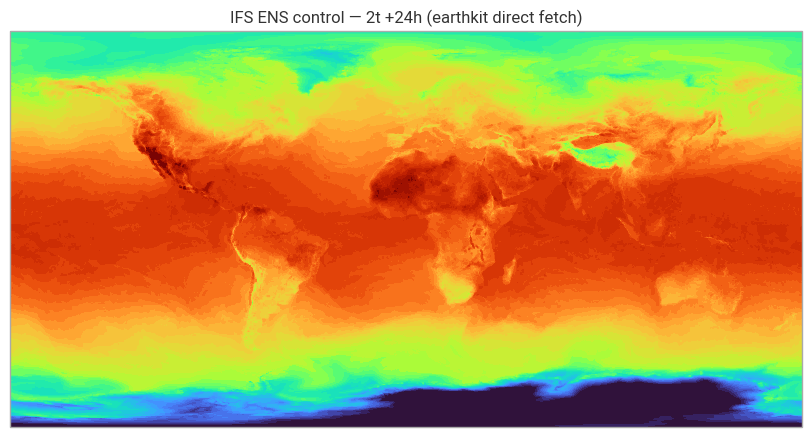

In [6]:
field = ds.sel(shortName="2t")[0]
m = ekp.Map()
m.quickplot(field)
m.title("IFS ENS control — 2t +24h (earthkit direct fetch)")
m.show()

### Troubleshooting
- **No steps found** — The run may not be published yet. Usually trying an earlier run fixes the issue.  
- **Plot fails** — Re-check the `shortName` in the Explore table; try `2t` or `msl` first.  

## Take-home messages

You have just:
- Understood the **ECMWF Open Data catalogue** structure and the **50r1 naming changes**
- Browsed the **live index** at `data.ecmwf.int` and picked a real run/step
- Downloaded a GRIB2 file using three methods (client, curl, HTTP Range)
- Inspected contents with `earthkit.data` and plotted a field by `shortName`

---

### Next steps

- **Notebook A02 — Open Data: retrieval and plotting with earthkit**  
  Automate safe run/step selection; fetch IFS, AIFS, and ENS; compare models; Africa domain; vertical profile.

- **Notebook A03 — Cloud endpoints (AWS S3, Azure, GCS)**  
  Fetch the same data without the `ecmwf-opendata` client using HTTP Range requests directly.

- **Notebook B01 — Copernicus ERA5 via CDS**  
  Access climate reanalysis (1940–present) using `cdsapi` and `earthkit.data`.

### Support & feedback

- Questions and bug reports: [support.ecmwf.int](https://support.ecmwf.int)
- Open Data documentation: [confluence.ecmwf.int/display/DAC/ECMWF+open+data](https://confluence.ecmwf.int/display/DAC/ECMWF+open+data)
- This notebook: [github.com/valtzen/demo](https://github.com/valtzen/demo)
